In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import confusion_matrix , classification_report,roc_auc_score,roc_curve,precision_recall_curve,precision_recall_fscore_support,auc,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split ,GridSearchCV ,StratifiedKFold , cross_val_predict

df= load_wine( as_frame = True ).frame
df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0,0
146,13.88,5.04,2.23,20.0,80.0,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415.0,2
55,13.56,1.73,2.46,20.5,116.0,2.96,2.78,0.20,2.45,6.25,0.98,3.03,1120.0,0
93,12.29,2.83,2.22,18.0,88.0,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290.0,1
133,12.70,3.55,2.36,21.5,106.0,1.70,1.20,0.17,0.84,5.00,0.78,1.29,600.0,2


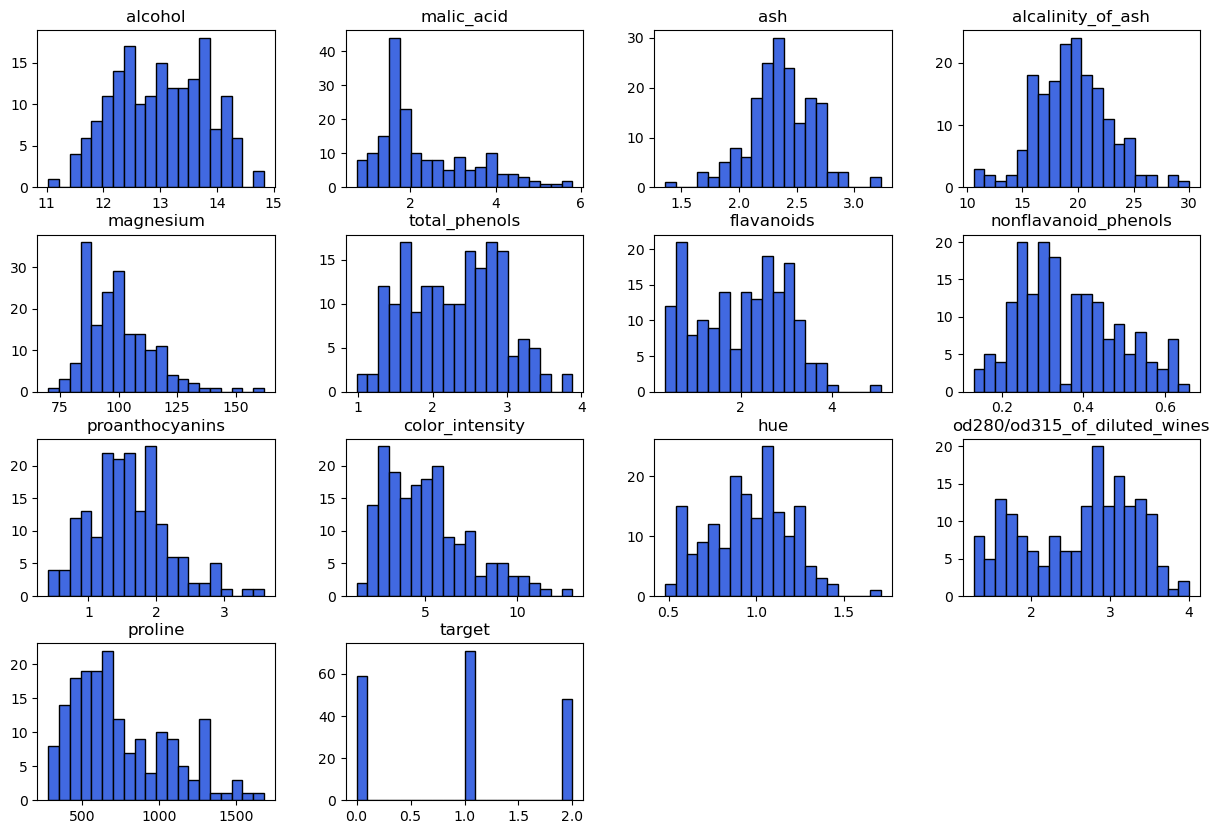

In [2]:
df.hist( figsize = (15,10), grid = False , bins = 20 , color ='royalblue' , edgecolor = 'black')
plt.show()

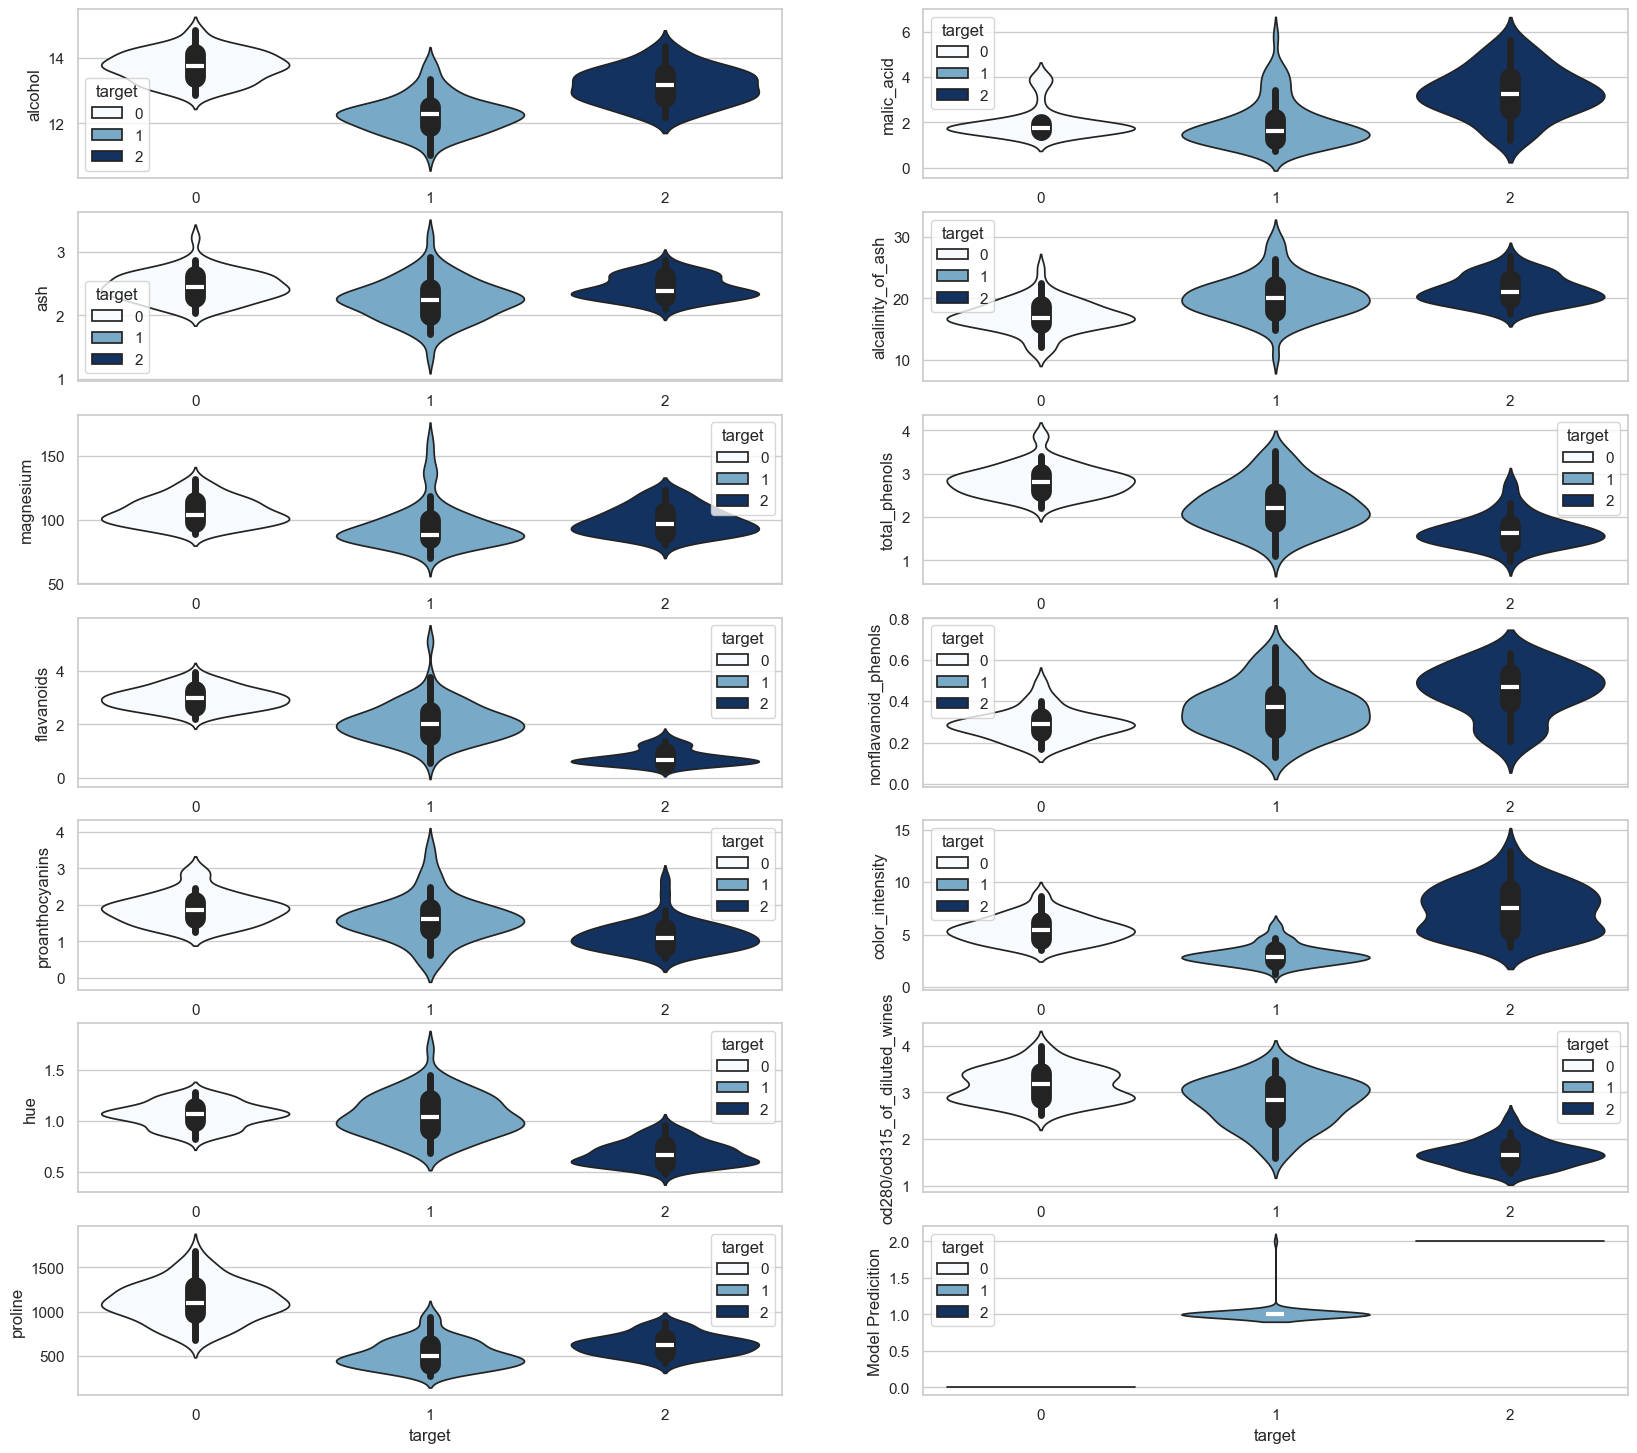

In [32]:
cols = df.drop(columns ='target').columns 
sns.set_theme(style="whitegrid", font="sans-serif")
fig , ax = plt.subplots( 7,2, figsize = ( 20, 18 ) )
ax= ax.flatten()
for idx , val in enumerate(cols ):
    sns.violinplot(data = df , y = val ,x  = 'target', hue = 'target',
                   palette = 'Blues' , ax = ax[idx] , inner_kws = {'box_width' : 15 }
                  )
plt.show()


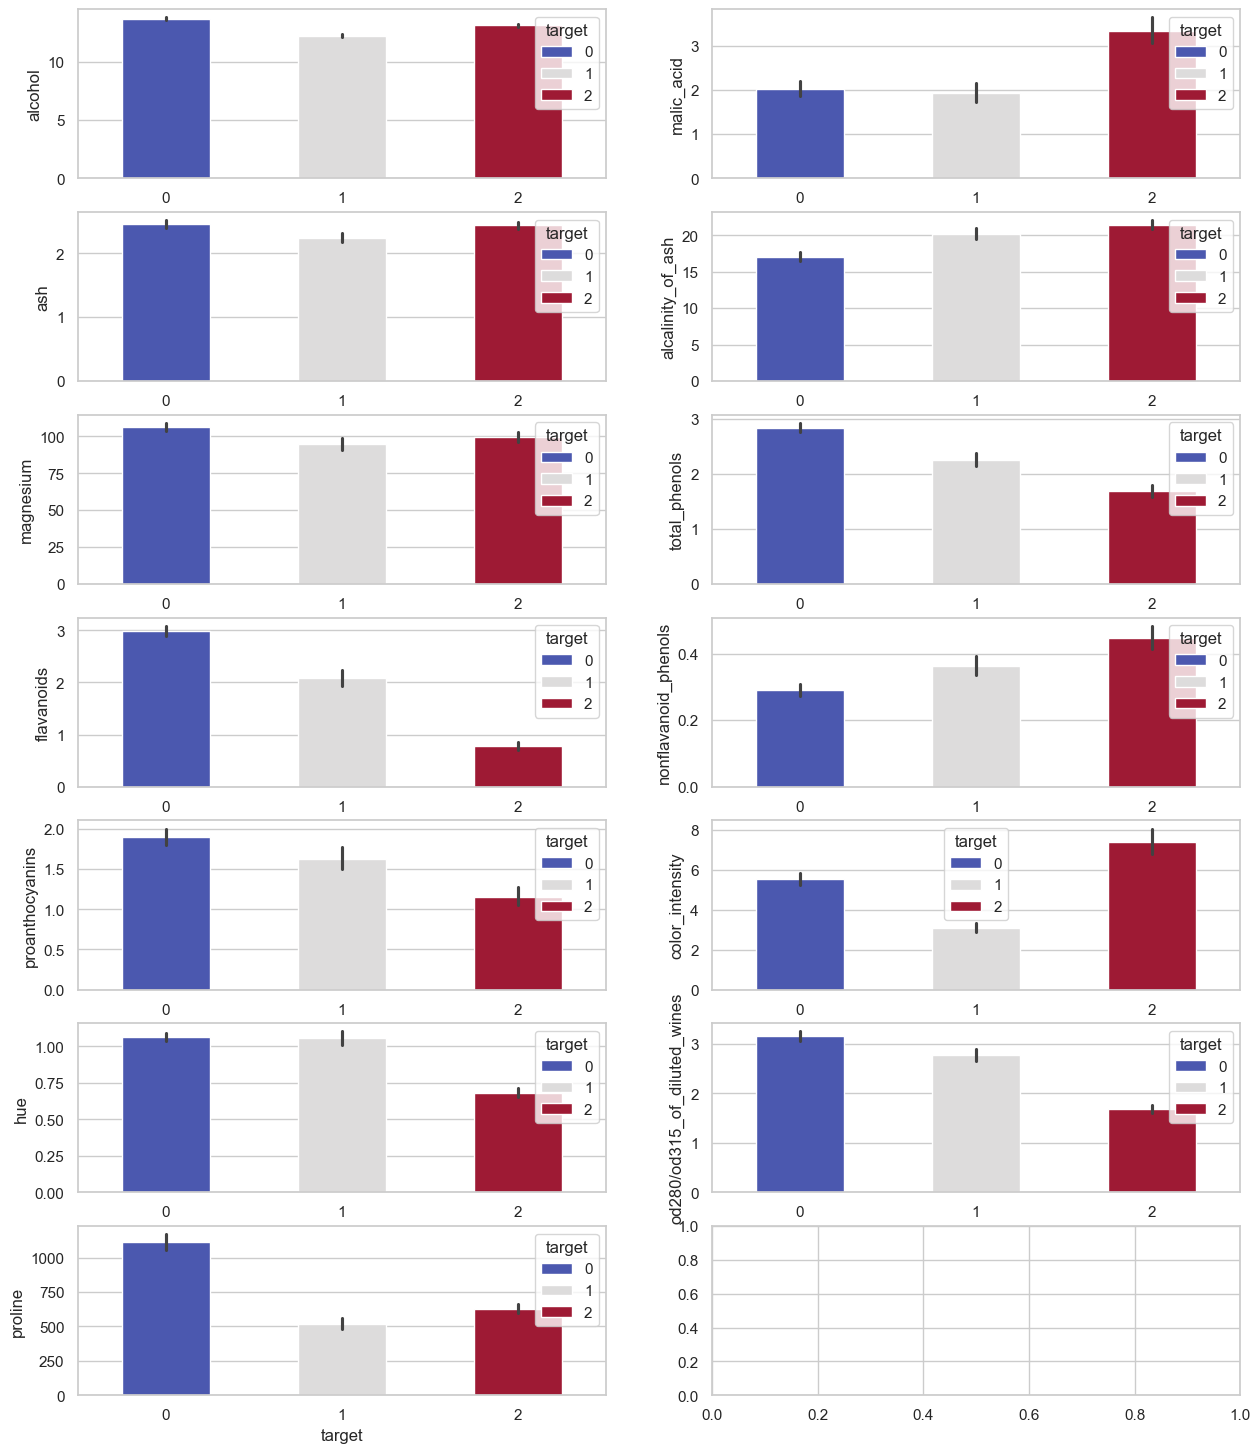

In [4]:
fig , ax = plt.subplots( 7,2, figsize = ( 15, 18 ) )
ax= ax.flatten()
for idx , val in enumerate(cols ):
    sns.barplot( data = df , x= 'target', y = val, hue ='target', ax = ax[idx] , estimator= 'mean', palette = 'coolwarm' , width= 0.5 )
plt.show()


<Figure size 1800x1400 with 0 Axes>

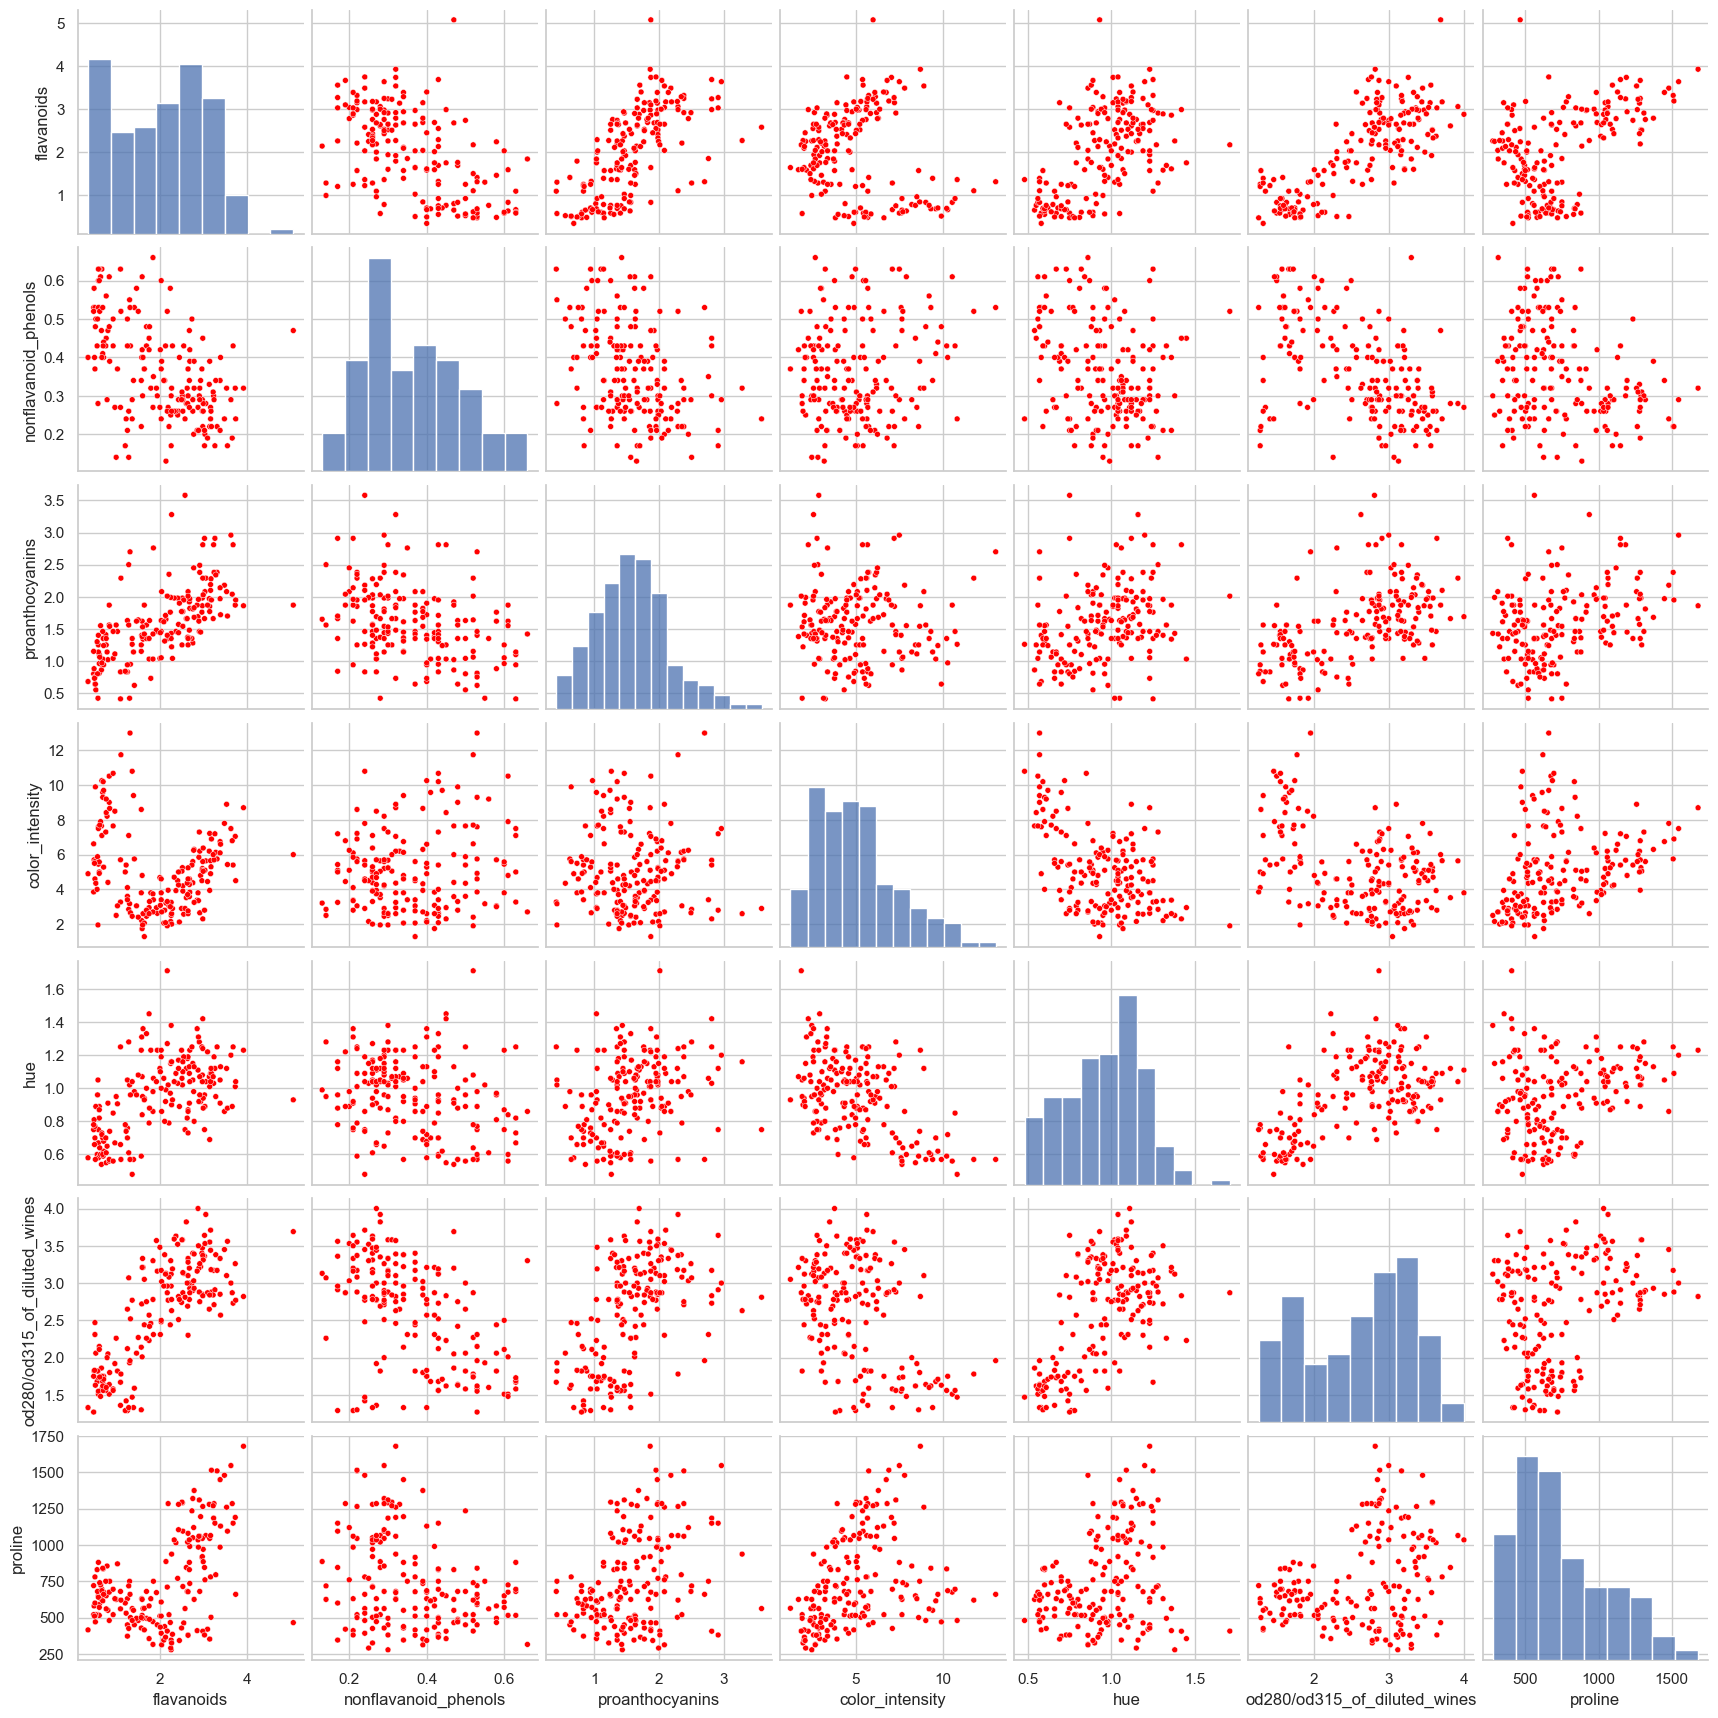

In [5]:
plt.figure( figsize = (18,14 ))  
sns.pairplot( df[cols[len(cols)//2: ] ] , plot_kws = {'color' : 'red' , 'size' : 50}   )
plt.show()

<Figure size 1800x1400 with 0 Axes>

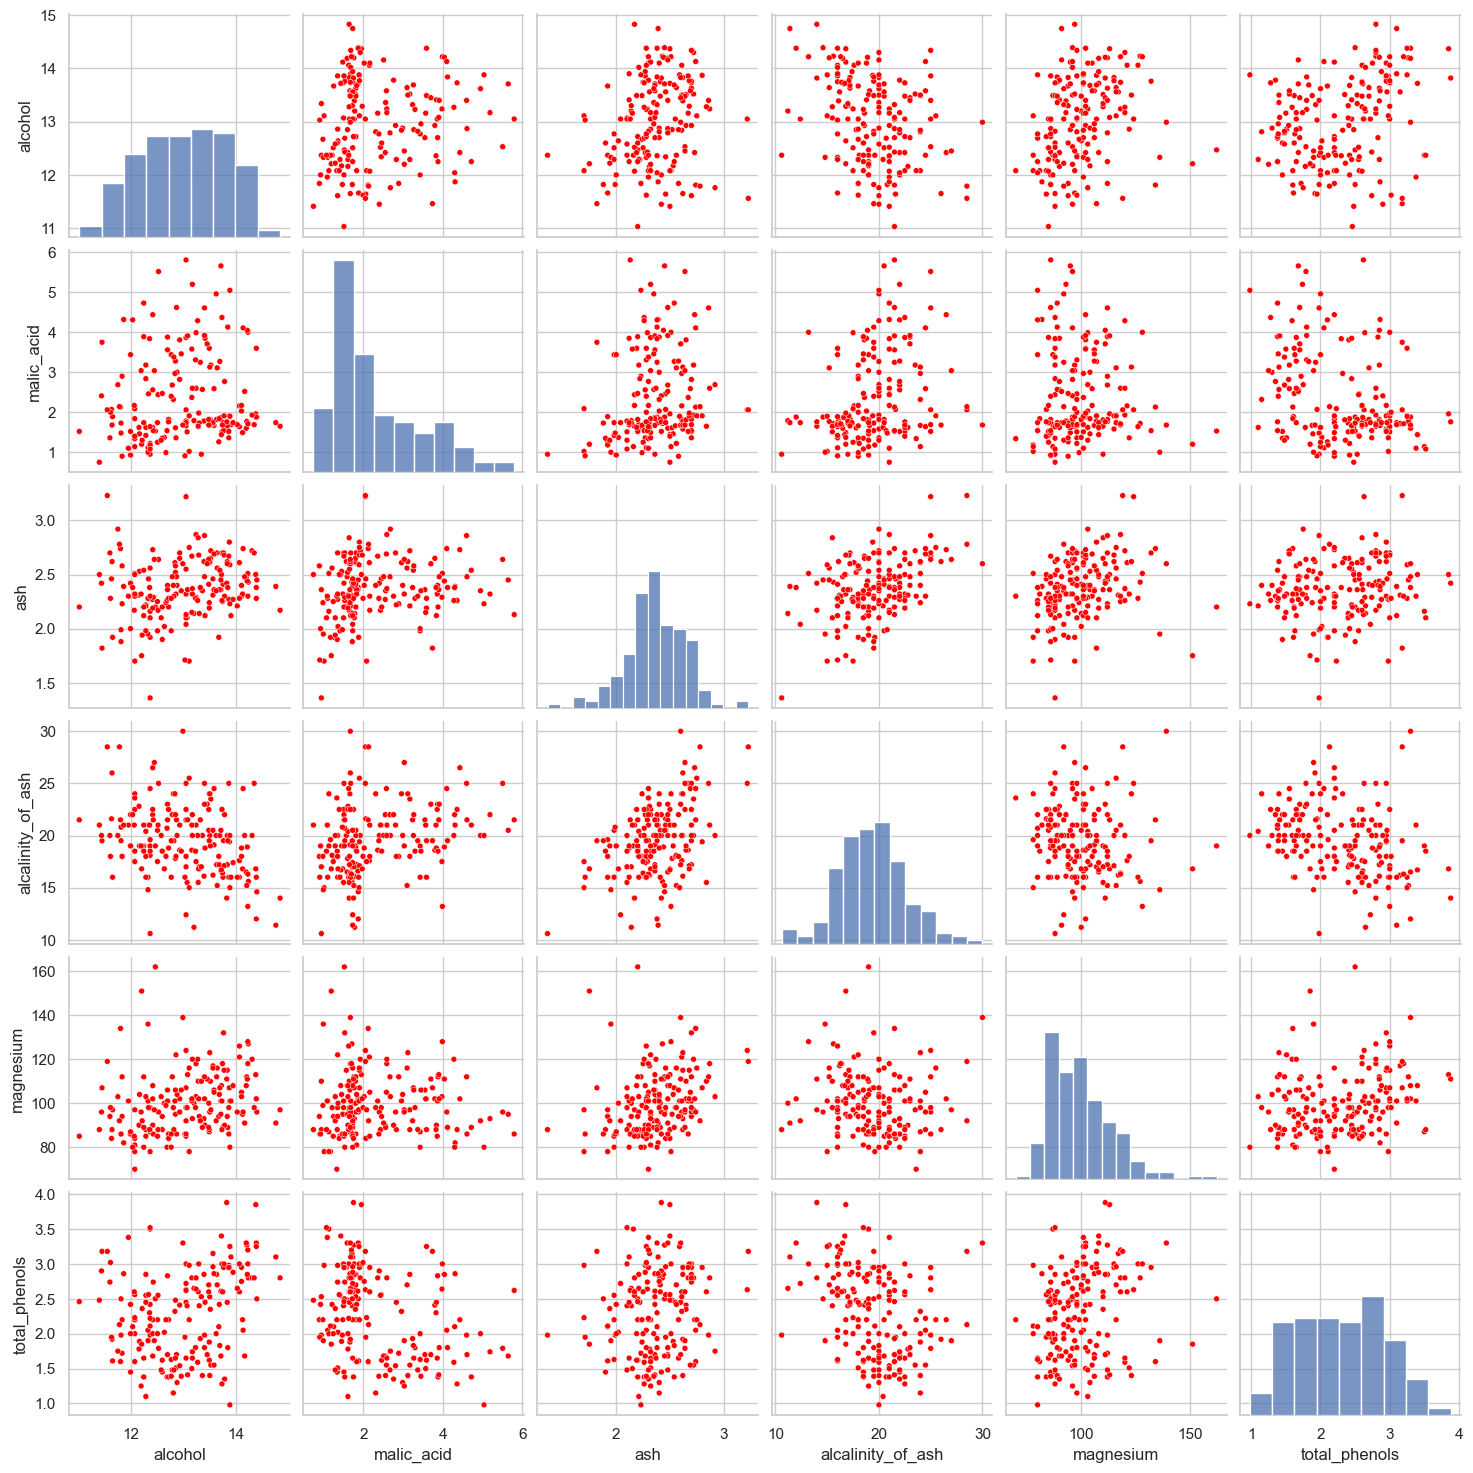

In [6]:
plt.figure( figsize = (18,14 ))  
sns.pairplot( df[cols[: len(cols)//2] ] , plot_kws = {'color' : 'red' , 'size' : 50}   )
plt.show()

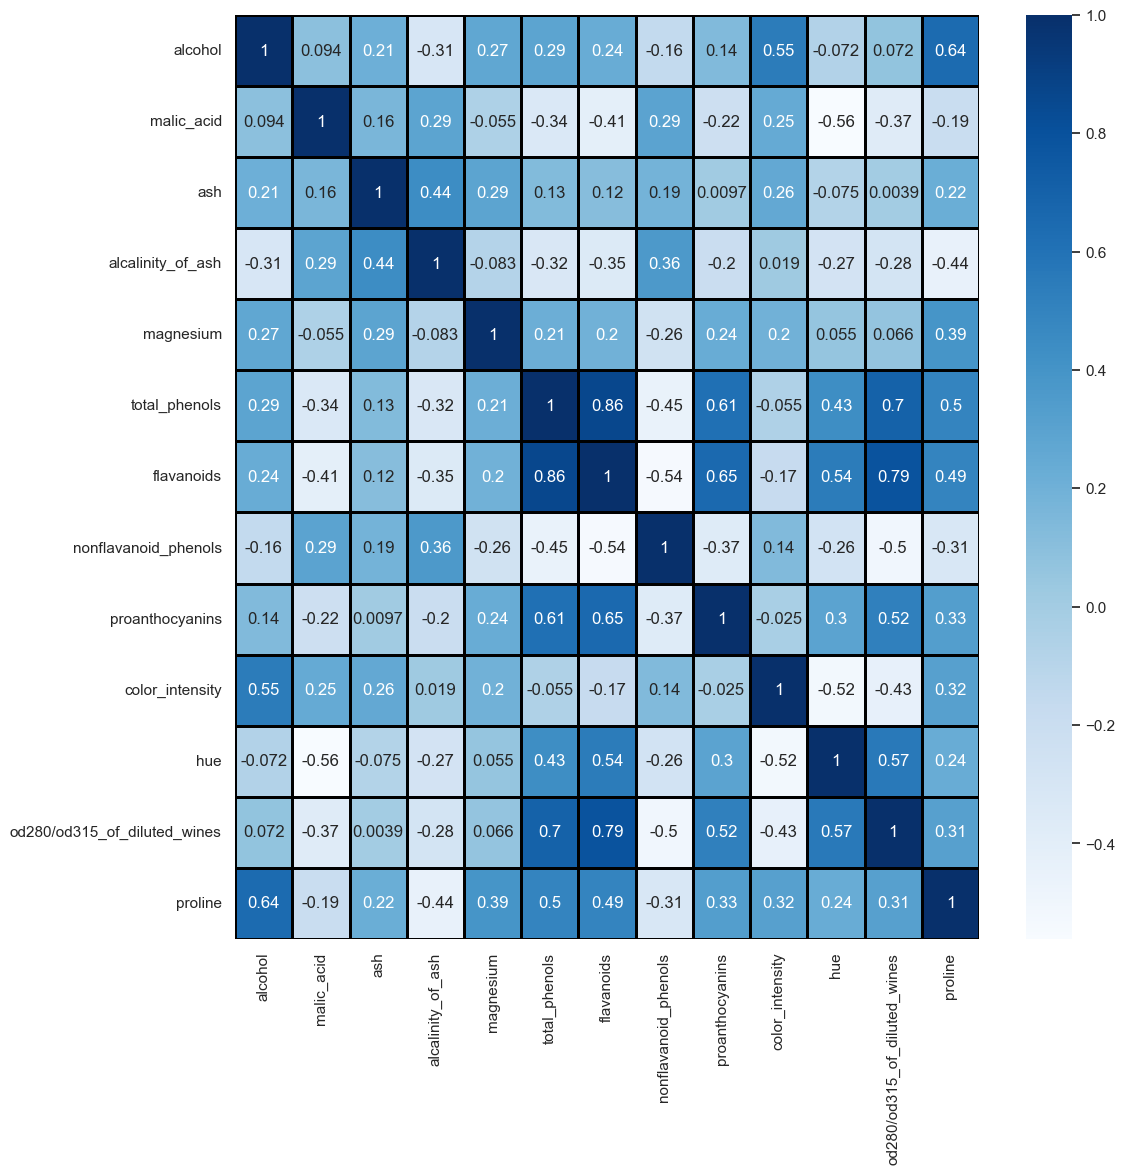

In [7]:
cols = df.drop('target', axis = 1).columns
corr = df[cols].corr()

plt.figure(figsize = ( 12,12))
sns.heatmap( corr, annot = True, cmap = 'Blues' , linecolor= 'black' , annot_kws= {'size' :12 } ,linewidths = 1 )
plt.show()



In [8]:
X = df.drop ( 'target' ,axis = 1 ) 
y=  df['target']
X_train, X_test, y_train, y_test = train_test_split ( X, y , test_size = 0.2 , shuffle = True , stratify=y ,random_state = 26) 
skfolds = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 26) 
pipeline = Pipeline( [
    ('scaling' , StandardScaler() ),
    ('model' , LogisticRegression(max_iter = 1000) )
])



In [30]:
param_grid = [
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__multi_class': ['ovr', 'multinomial'],
        'model__C': [0.1, 0.2, 0.9, 5, 10],
        'model__solver': ['lbfgs', 'saga']
    },
    {
        'model': [OneVsOneClassifier(LogisticRegression(max_iter=1000))],
        'model__estimator__C': [0.1, 0.2, 0.9, 5, 10]
    }
]

grid_search = GridSearchCV(pipeline, param_grid, cv=skfolds, scoring='f1_macro')
grid_search.fit(X_train, y_train)
warnings.filterwarnings('ignore')
print("Best params:", grid_search.best_params_)
print("Best CV F1-macro:", grid_search.best_score_)
warnings.filterwarnings('ignore')

Best params: {'model': LogisticRegression(max_iter=1000), 'model__C': 0.1, 'model__multi_class': 'ovr', 'model__solver': 'lbfgs'}
Best CV F1-macro: 0.9929038281979459


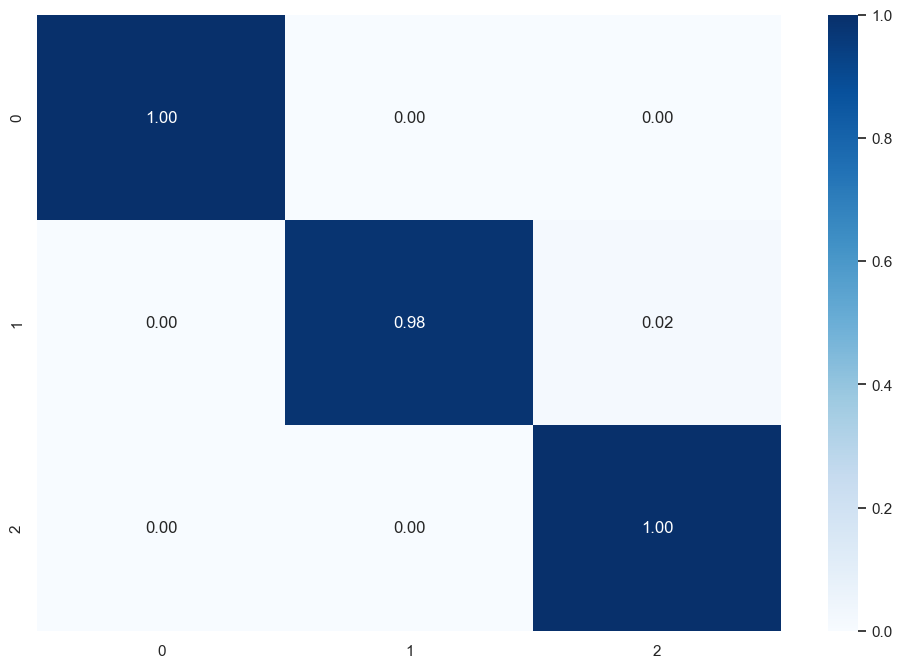

In [10]:
model  = grid_search.best_estimator_
y_train_pred = cross_val_predict(model ,X_train ,y_train ,cv = skfolds)
cm = confusion_matrix( y_train ,y_train_pred, normalize = 'true')
plt.figure( figsize = (12,8))
sns.heatmap( cm, cmap ='Blues', annot = True , fmt= '.2f')
plt.show()

In [11]:
data =classification_report(y_train ,y_train_pred ,target_names = ['class_0' ,'class_1', 'class_2'] ,output_dict = True)
df2 = pd.DataFrame( data )
df2.transpose()

,precision,recall,f1-score,support
class_0,1.000000,1.000000,1.000000,47.000000
class_1,1.000000,0.982456,0.991150,57.000000
class_2,0.974359,1.000000,0.987013,38.000000
accuracy,0.992958,0.992958,0.992958,0.992958
macro avg,0.991453,0.994152,0.992721,142.000000
weighted avg,0.993138,0.992958,0.992972,142.000000


macro_avg average the score treating each class as equally , 

the weighted average divides scores x samplesnumber / total samples in the dataset

support is appearance of samples in the dataset

In [12]:
df['Model Predicition'] = model.predict(X)
df.sample(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,Model Predicition
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,0
29,14.02,1.68,2.21,16.0,96.0,2.65,2.33,0.26,1.98,4.70,1.04,3.59,1035.0,0,0
42,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0,0,0
66,13.11,1.01,1.70,15.0,78.0,2.98,3.18,0.26,2.28,5.30,1.12,3.18,502.0,1,1


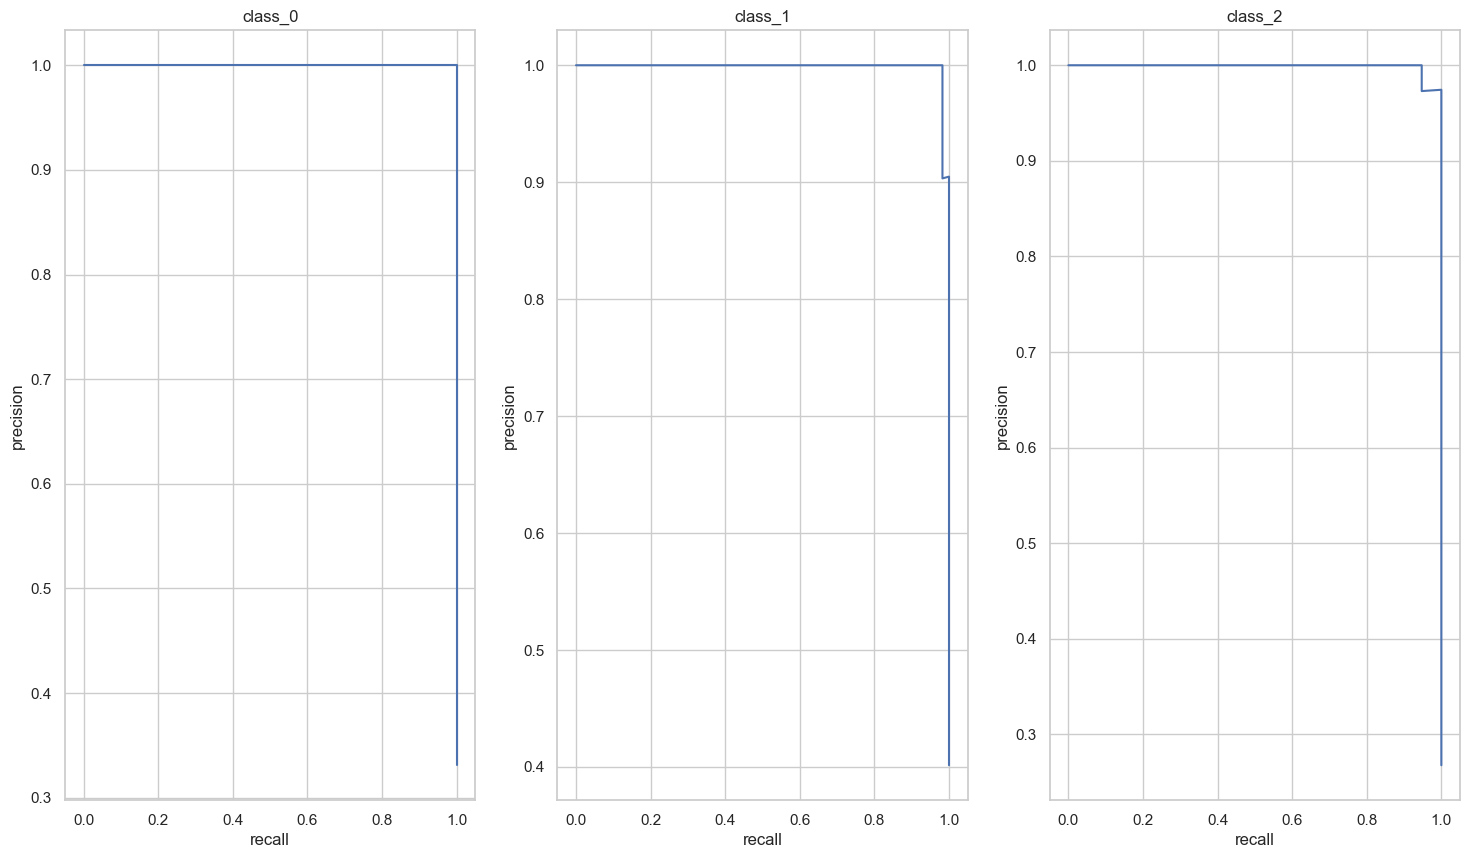

In [13]:
classes= ['class_0', 'class_1' ,'class_2' ]
fig ,ax = plt.subplots(1,3 ,figsize =(18,10))
for i,v in enumerate(classes):
    y_train_proba = cross_val_predict(model, X_train,y_train,cv=skfolds,method ='predict_proba')[:,i]
    p,r,thr = precision_recall_curve(y_train, y_train_proba, pos_label = i )
    ax[i].plot(r ,p )
    ax[i].grid(True)
    ax[i].set_title(v)
    ax[i].set_xlabel('recall')
    ax[i].set_ylabel('precision')
plt.show()

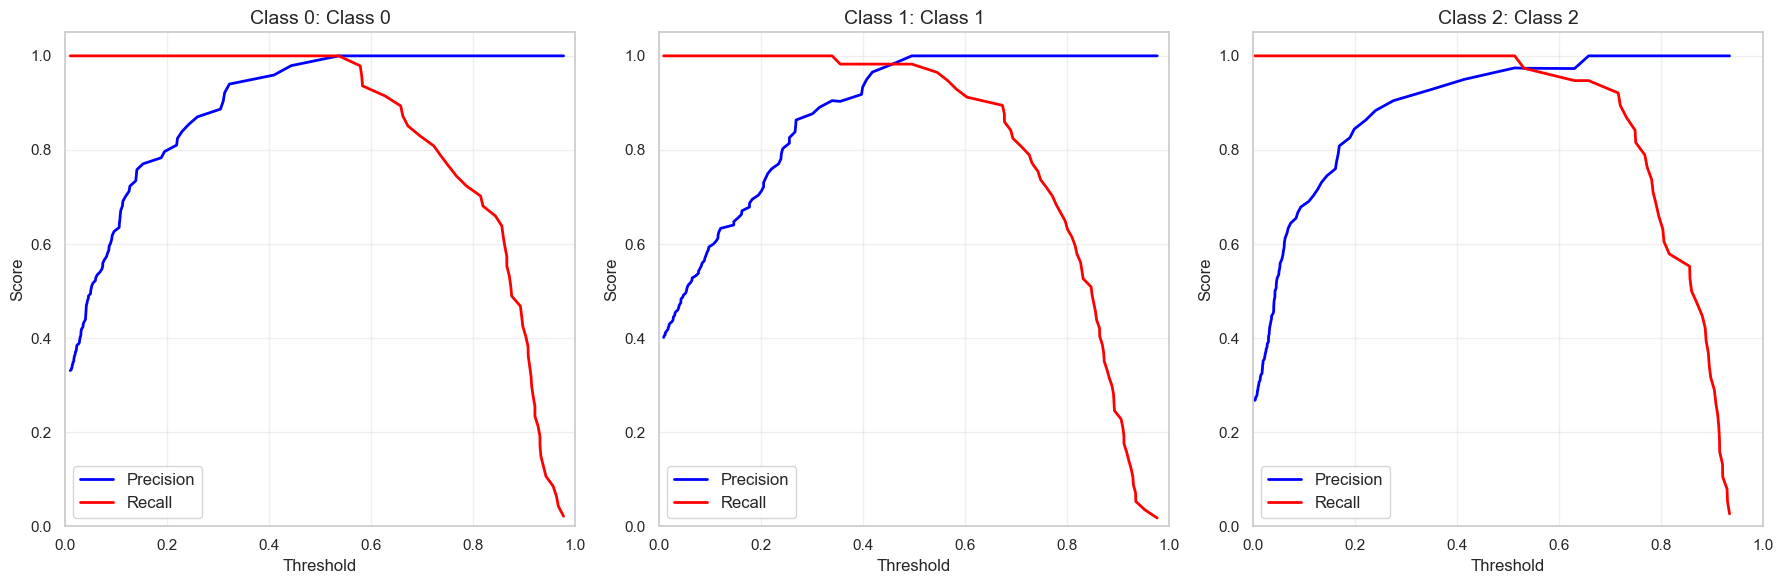

In [14]:
classes = ['Class 0', 'Class 1', 'Class 2']
y_train_proba = cross_val_predict(
    model, 
    X_train, 
    y_train, 
    cv=skfolds, 
    method='predict_proba'
)
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, class_name in enumerate(classes):
    y_proba_class = y_train_proba[:, i]
    
    precision, recall, thresholds = precision_recall_curve(
        y_train, 
        y_proba_class, 
        pos_label=i
    )
    ax[i].plot(thresholds, precision[:-1], label='Precision', color='blue', linewidth=2)
    ax[i].plot(thresholds, recall[:-1], label='Recall', color='red', linewidth=2)
    ax[i].set_title(f'Class {i}: {class_name}', fontsize=14)
    ax[i].set_xlabel('Threshold', fontsize=12)
    ax[i].set_ylabel('Score', fontsize=12)
    ax[i].legend(fontsize=12)
    ax[i].grid(True, alpha=0.3)
    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

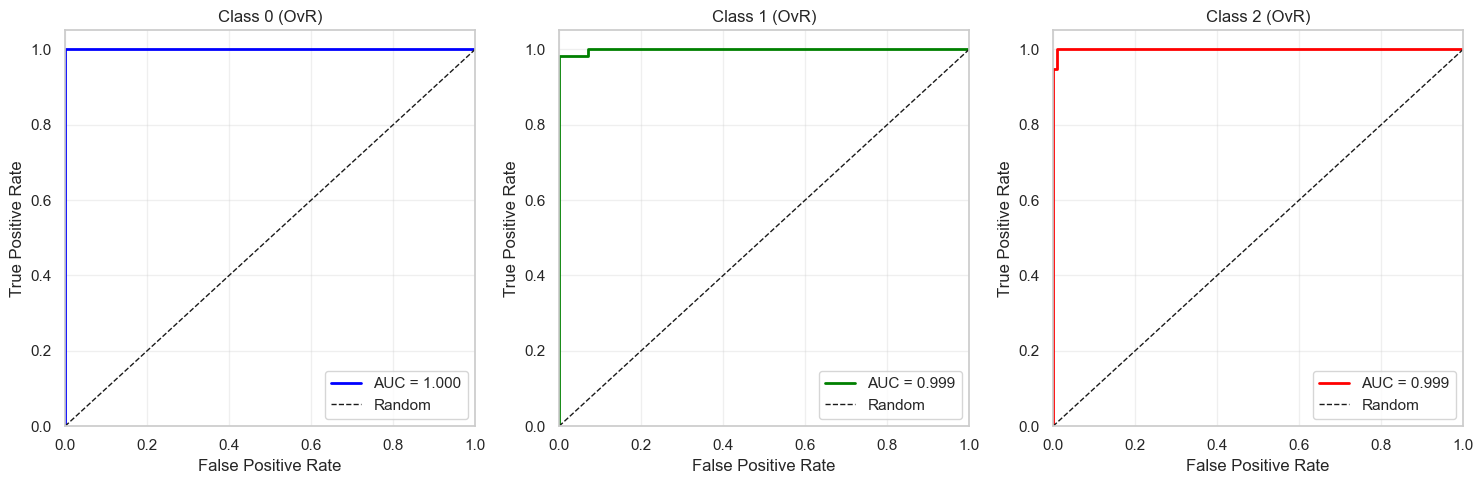

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
class_names = ['Class 0', 'Class 1', 'Class 2']
colors = ['blue', 'green', 'red']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[i].plot(fpr, tpr, color=colors[i], lw=2, 
                 label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{class_names[i]} (OvR)')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

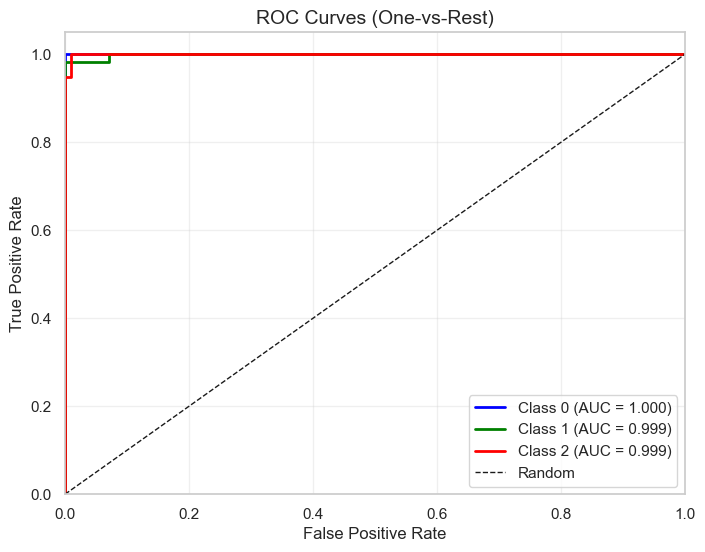

In [16]:
plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_train == i, y_train_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
grid_search.best_params_

{'model': LogisticRegression(max_iter=1000),
 'model__C': 0.1,
 'model__multi_class': 'ovr',
 'model__solver': 'lbfgs'}

In [18]:
coef_df=pd.DataFrame( model.named_steps['model'].coef_ ,
              index = ['class_0', 'class_1' , 'class_2' ] ,
              columns=model.feature_names_in_ )
coef_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,0.681172,0.101690,0.352876,-0.549113,0.106599,0.259703,0.441472,-0.220356,0.087441,0.128116,0.087148,0.481648,0.848514
class_1,-0.805461,-0.421533,-0.406755,0.312483,-0.118809,0.049663,0.140960,0.128531,0.072625,-0.782367,0.505762,0.128240,-0.779372
class_2,0.164585,0.344769,0.121333,0.191398,0.055842,-0.362265,-0.603239,0.091790,-0.310171,0.554777,-0.636175,-0.620911,-0.032587


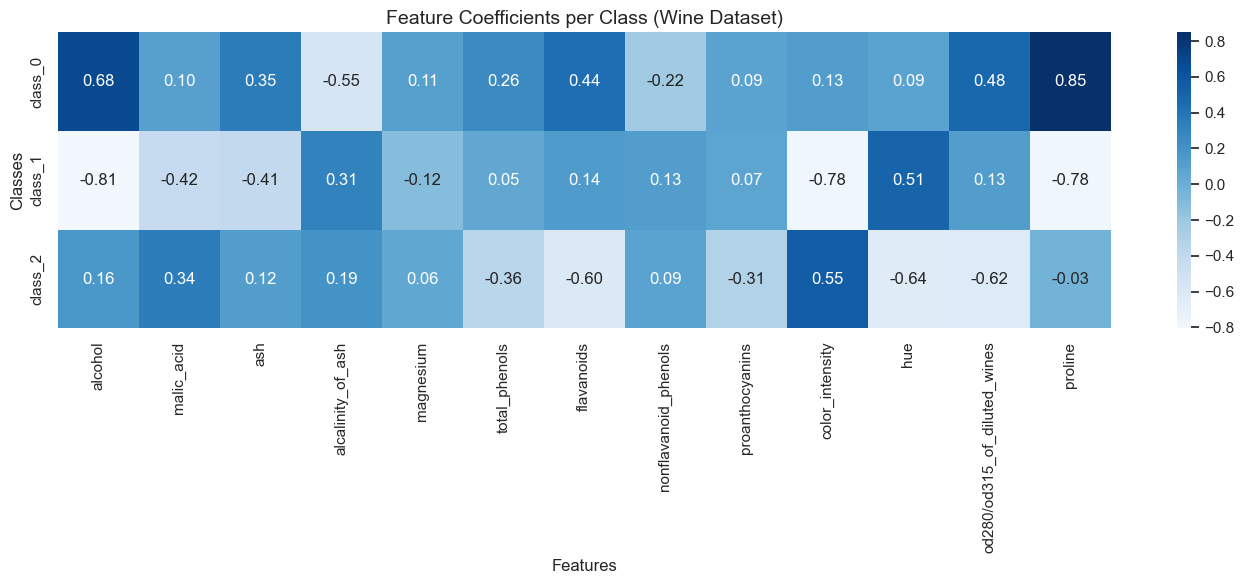

In [19]:
plt.figure(figsize=(14, 6))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Feature Coefficients per Class (Wine Dataset)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Classes', fontsize=12)
plt.tight_layout()
plt.show()

For each class, a positive coefficient means: as this feature increases, the log-odds of belonging to THIS class increase.

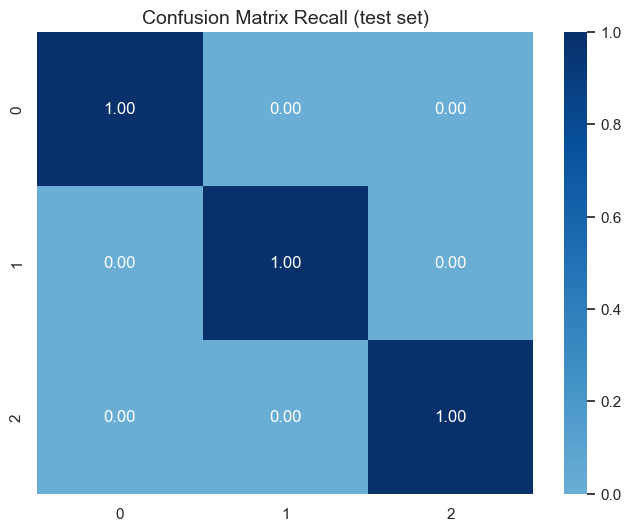

In [20]:
y_pred = model.predict(X_test) 
cm = confusion_matrix(y_test, y_pred, normalize = 'true' )
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Confusion Matrix Recall (test set)', fontsize=14)
plt.show()


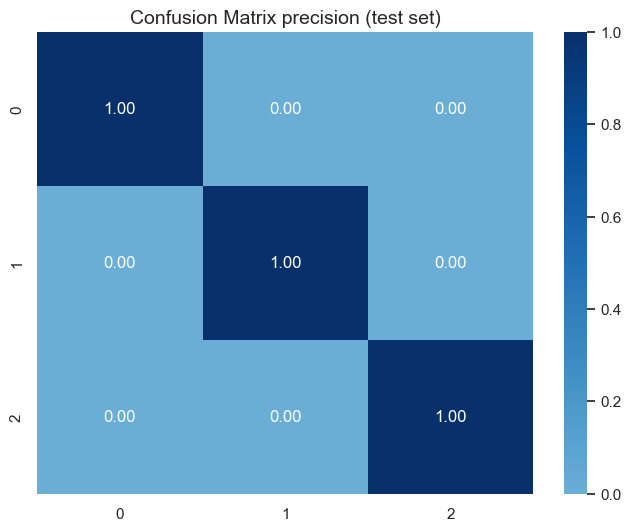

In [21]:
y_pred = model.predict(X_test) 
cm = confusion_matrix(y_test, y_pred, normalize = 'pred' )
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Confusion Matrix precision (test set)', fontsize=14)
plt.show()


In [22]:
f1_score(y_test, y_pred , average='macro')

1.0

In [23]:
grid_search.best_score_

np.float64(0.9929038281979459)

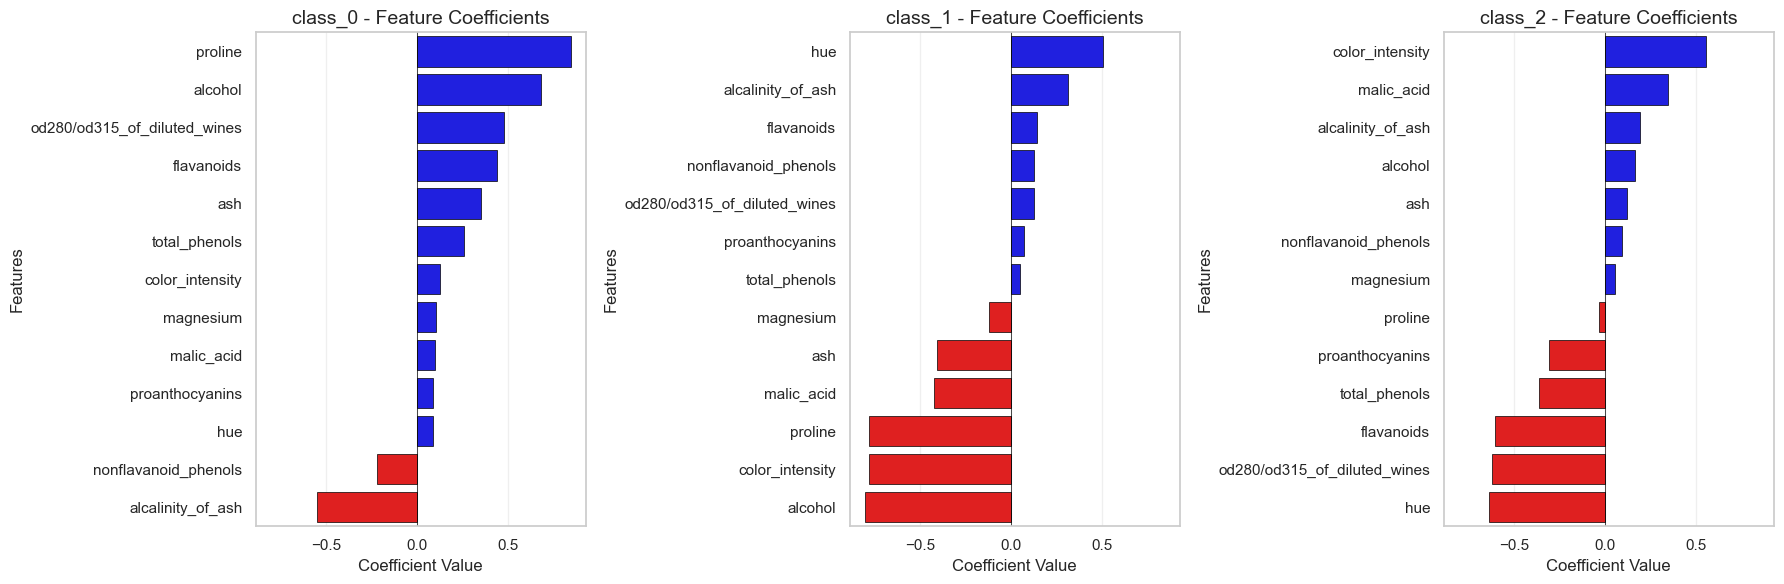

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
class_names = coef_df.index
for i, cls in enumerate(class_names):
    sorted_coef = coef_df.loc[cls].sort_values(ascending=False)
    colors = ['blue' if val > 0 else 'red' for val in sorted_coef.values]
    
    sns.barplot(
        x=sorted_coef.values, 
        y=sorted_coef.index, 
        palette=colors,  
        ax=ax[i],
        edgecolor='black',
        linewidth=0.5
    )
    
    ax[i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax[i].set_title(f'{cls} - Feature Coefficients', fontsize=14)
    ax[i].set_xlabel('Coefficient Value', fontsize=12)
    ax[i].set_ylabel('Features', fontsize=12)
    ax[i].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [25]:
model_2 = LogisticRegression(max_iter = 1000 ,solver='lbfgs' , multi_class='multinomial')
model_2.fit  (X_train , y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [26]:

coef_matrix = model_2.coef_

baseline = coef_matrix[0] 
coef_vs_baseline = coef_matrix - baseline

coef_2df = pd.DataFrame ( coef_vs_baseline, index= ['class_0' , 'class_1' ,'class_2' ],
                          columns= model_2.feature_names_in_ )
coef_2df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
class_1,0.714309,-1.021491,-1.229095,0.490748,0.030094,0.744619,-0.776448,0.25245,0.334710,-0.998151,1.048557,-0.716888,-0.020097
class_2,-0.002380,-0.208120,-0.736132,0.512855,0.041795,-0.231363,-1.937144,-0.39621,-0.203782,0.630002,-0.289320,-1.516242,-0.009900


For Ovr means the change in feature X (one unit) changes the log odds by that coeffecient of that class vs others(others treated as zero)


in multinomial Feature increases log-odds of this class vs the BASELINE class

"How this feature affects odds of being Class 0 vs NOT Class 0"

"How this feature affects odds of being Class 0 vs the baseline class"

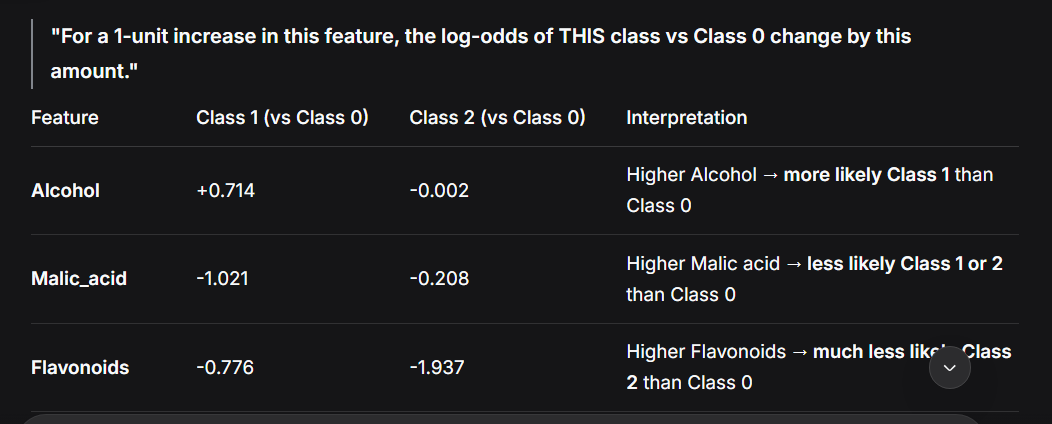

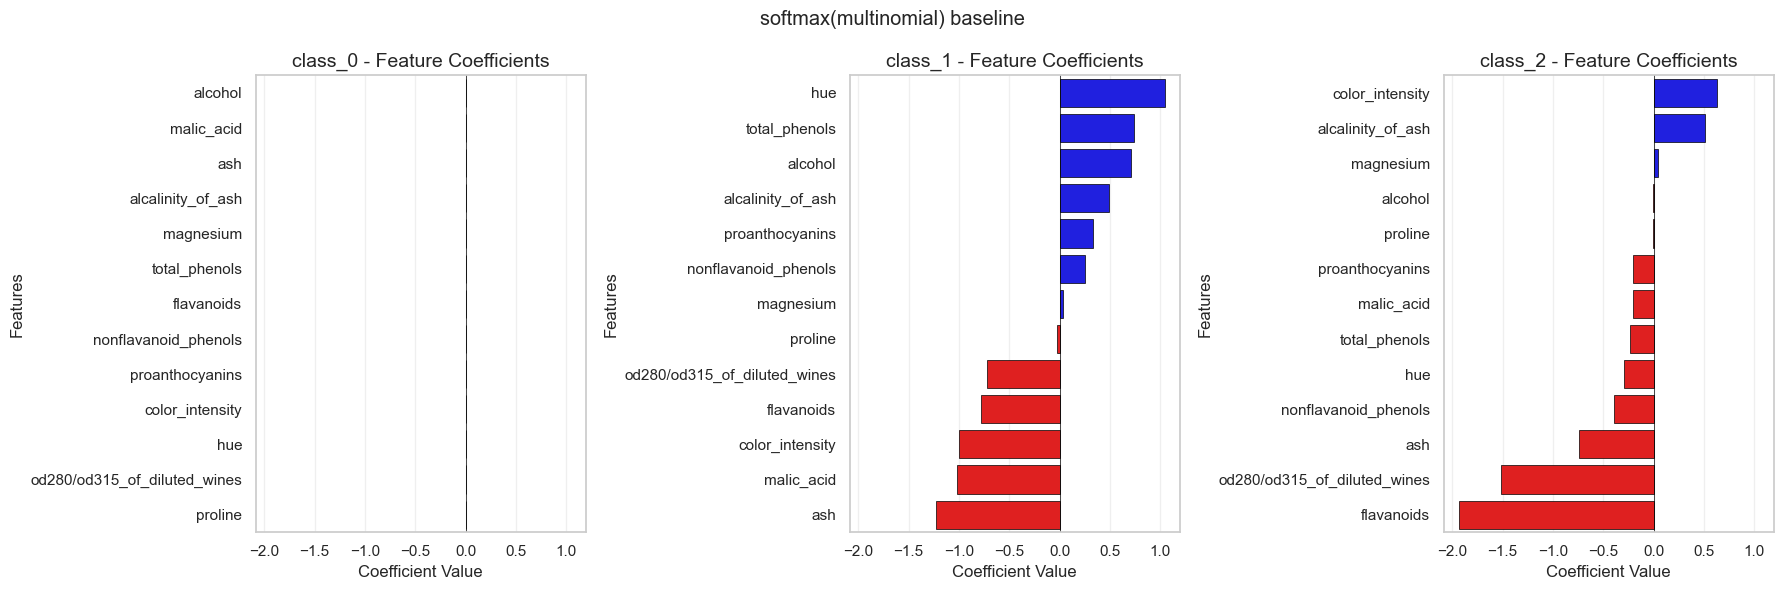

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
class_names = coef_2df.index
for i, cls in enumerate(class_names):
    sorted_coef = coef_2df.loc[cls].sort_values(ascending=False)
    colors = ['blue' if val > 0 else 'red' for val in sorted_coef.values]
    
    sns.barplot(
        x=sorted_coef.values, 
        y=sorted_coef.index, 
        palette=colors,  
        ax=ax[i],
        edgecolor='black',
        linewidth=0.5
    )
    
    ax[i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax[i].set_title(f'{cls} - Feature Coefficients', fontsize=14)
    ax[i].set_xlabel('Coefficient Value', fontsize=12)
    ax[i].set_ylabel('Features', fontsize=12)
    ax[i].grid(True, alpha=0.3, axis='x')
plt.suptitle('softmax(multinomial) baseline')
plt.tight_layout()
plt.show()

In [28]:
model.predict_proba( [ X_test.iloc[30] ] )

array([[0.02279065, 0.49773372, 0.47947563]])

In [29]:
y_test.iloc[30]

np.int64(1)